In [1]:
# Install and import all required libraries
!pip install pandas numpy matplotlib seaborn faker -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker
import random
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
fake = Faker()

print("All libraries imported successfully!")
print("Let's build a RoboTaxi Operations Analytics Dashboard!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 42.2 MB/s eta 0:00:00
All libraries imported successfully!
Let's build a RoboTaxi Operations Analytics Dashboard!


In [2]:
# Generate RoboTaxi Operations Dataset
n_vehicles = 200
n_days = 90
regions = ['Phoenix AZ', 'Austin TX', 'Las Vegas NV', 'San Francisco CA', 'Miami FL']
vehicle_models = ['Model 3', 'Model Y', 'Cybercab']
technician_levels = ['Junior', 'Mid', 'Senior']
repair_types = ['Robotaxi Repair', 'B2B Customer', 'Tesla Fleet', 'Scheduled Maintenance', 'Emergency Repair']
issue_categories = ['Sensor Failure', 'Software Update', 'Battery Issue', 'Brake System', 'Camera Calibration', 'Tire Replacement', 'Electrical Issue']

# Generate vehicle fleet
vehicles = []
for i in range(n_vehicles):
    vehicles.append({
        'vehicle_id': f'RBT{i+1:04d}',
        'model': random.choice(vehicle_models),
        'region': random.choice(regions),
        'mileage': random.randint(5000, 150000),
        'age_months': random.randint(1, 48)
    })

vehicles_df = pd.DataFrame(vehicles)

# Generate daily operations records
records = []
start_date = datetime.now() - timedelta(days=n_days)

for day in range(n_days):
    date = start_date + timedelta(days=day)
    daily_vehicles = random.randint(80, 150)

    for _ in range(daily_vehicles):
        vehicle = vehicles_df.sample(1).iloc[0]
        repair_type = random.choice(repair_types)
        issue = random.choice(issue_categories)
        technician = random.choice(technician_levels)

        # Service cycle time based on repair type
        if repair_type == 'Emergency Repair':
            service_time = random.uniform(2.0, 8.0)
        elif repair_type == 'Scheduled Maintenance':
            service_time = random.uniform(0.5, 2.0)
        else:
            service_time = random.uniform(1.0, 5.0)

        # MTBF based on vehicle age
        mtbf = max(50, 500 - vehicle['age_months'] * 8 + random.uniform(-20, 20))

        # Uptime percentage
        uptime = max(0.75, min(0.99, 0.95 - (service_time / 24) + random.uniform(-0.02, 0.02)))

        records.append({
            'date': date.strftime('%Y-%m-%d'),
            'vehicle_id': vehicle['vehicle_id'],
            'model': vehicle['model'],
            'region': vehicle['region'],
            'repair_type': repair_type,
            'issue_category': issue,
            'technician_level': technician,
            'service_cycle_time_hrs': round(service_time, 2),
            'mtbf_hours': round(mtbf, 2),
            'fleet_uptime_pct': round(uptime * 100, 2),
            'resolution_rate': round(random.uniform(0.85, 0.99), 3),
            'parts_cost': round(random.uniform(50, 2000), 2),
            'labor_cost': round(service_time * random.uniform(75, 150), 2),
        })

ops_df = pd.DataFrame(records)
ops_df['date'] = pd.to_datetime(ops_df['date'])
ops_df['total_cost'] = ops_df['parts_cost'] + ops_df['labor_cost']

print(f"Dataset generated successfully!")
print(f"Total service records: {len(ops_df):,}")
print(f"Vehicles tracked: {n_vehicles}")
print(f"Days of data: {n_days}")
print(f"Avg Service Cycle Time: {ops_df['service_cycle_time_hrs'].mean():.2f} hrs")
print(f"Avg Fleet Uptime: {ops_df['fleet_uptime_pct'].mean():.2f}%")
print(f"Avg MTBF: {ops_df['mtbf_hours'].mean():.2f} hrs")
print(f"Total Operations Cost: ${ops_df['total_cost'].sum():,.2f}")

Dataset generated successfully!
Total service records: 10,577
Vehicles tracked: 200
Days of data: 90
Avg Service Cycle Time: 3.04 hrs
Avg Fleet Uptime: 83.07%
Avg MTBF: 308.39 hrs
Total Operations Cost: $14,404,789.52


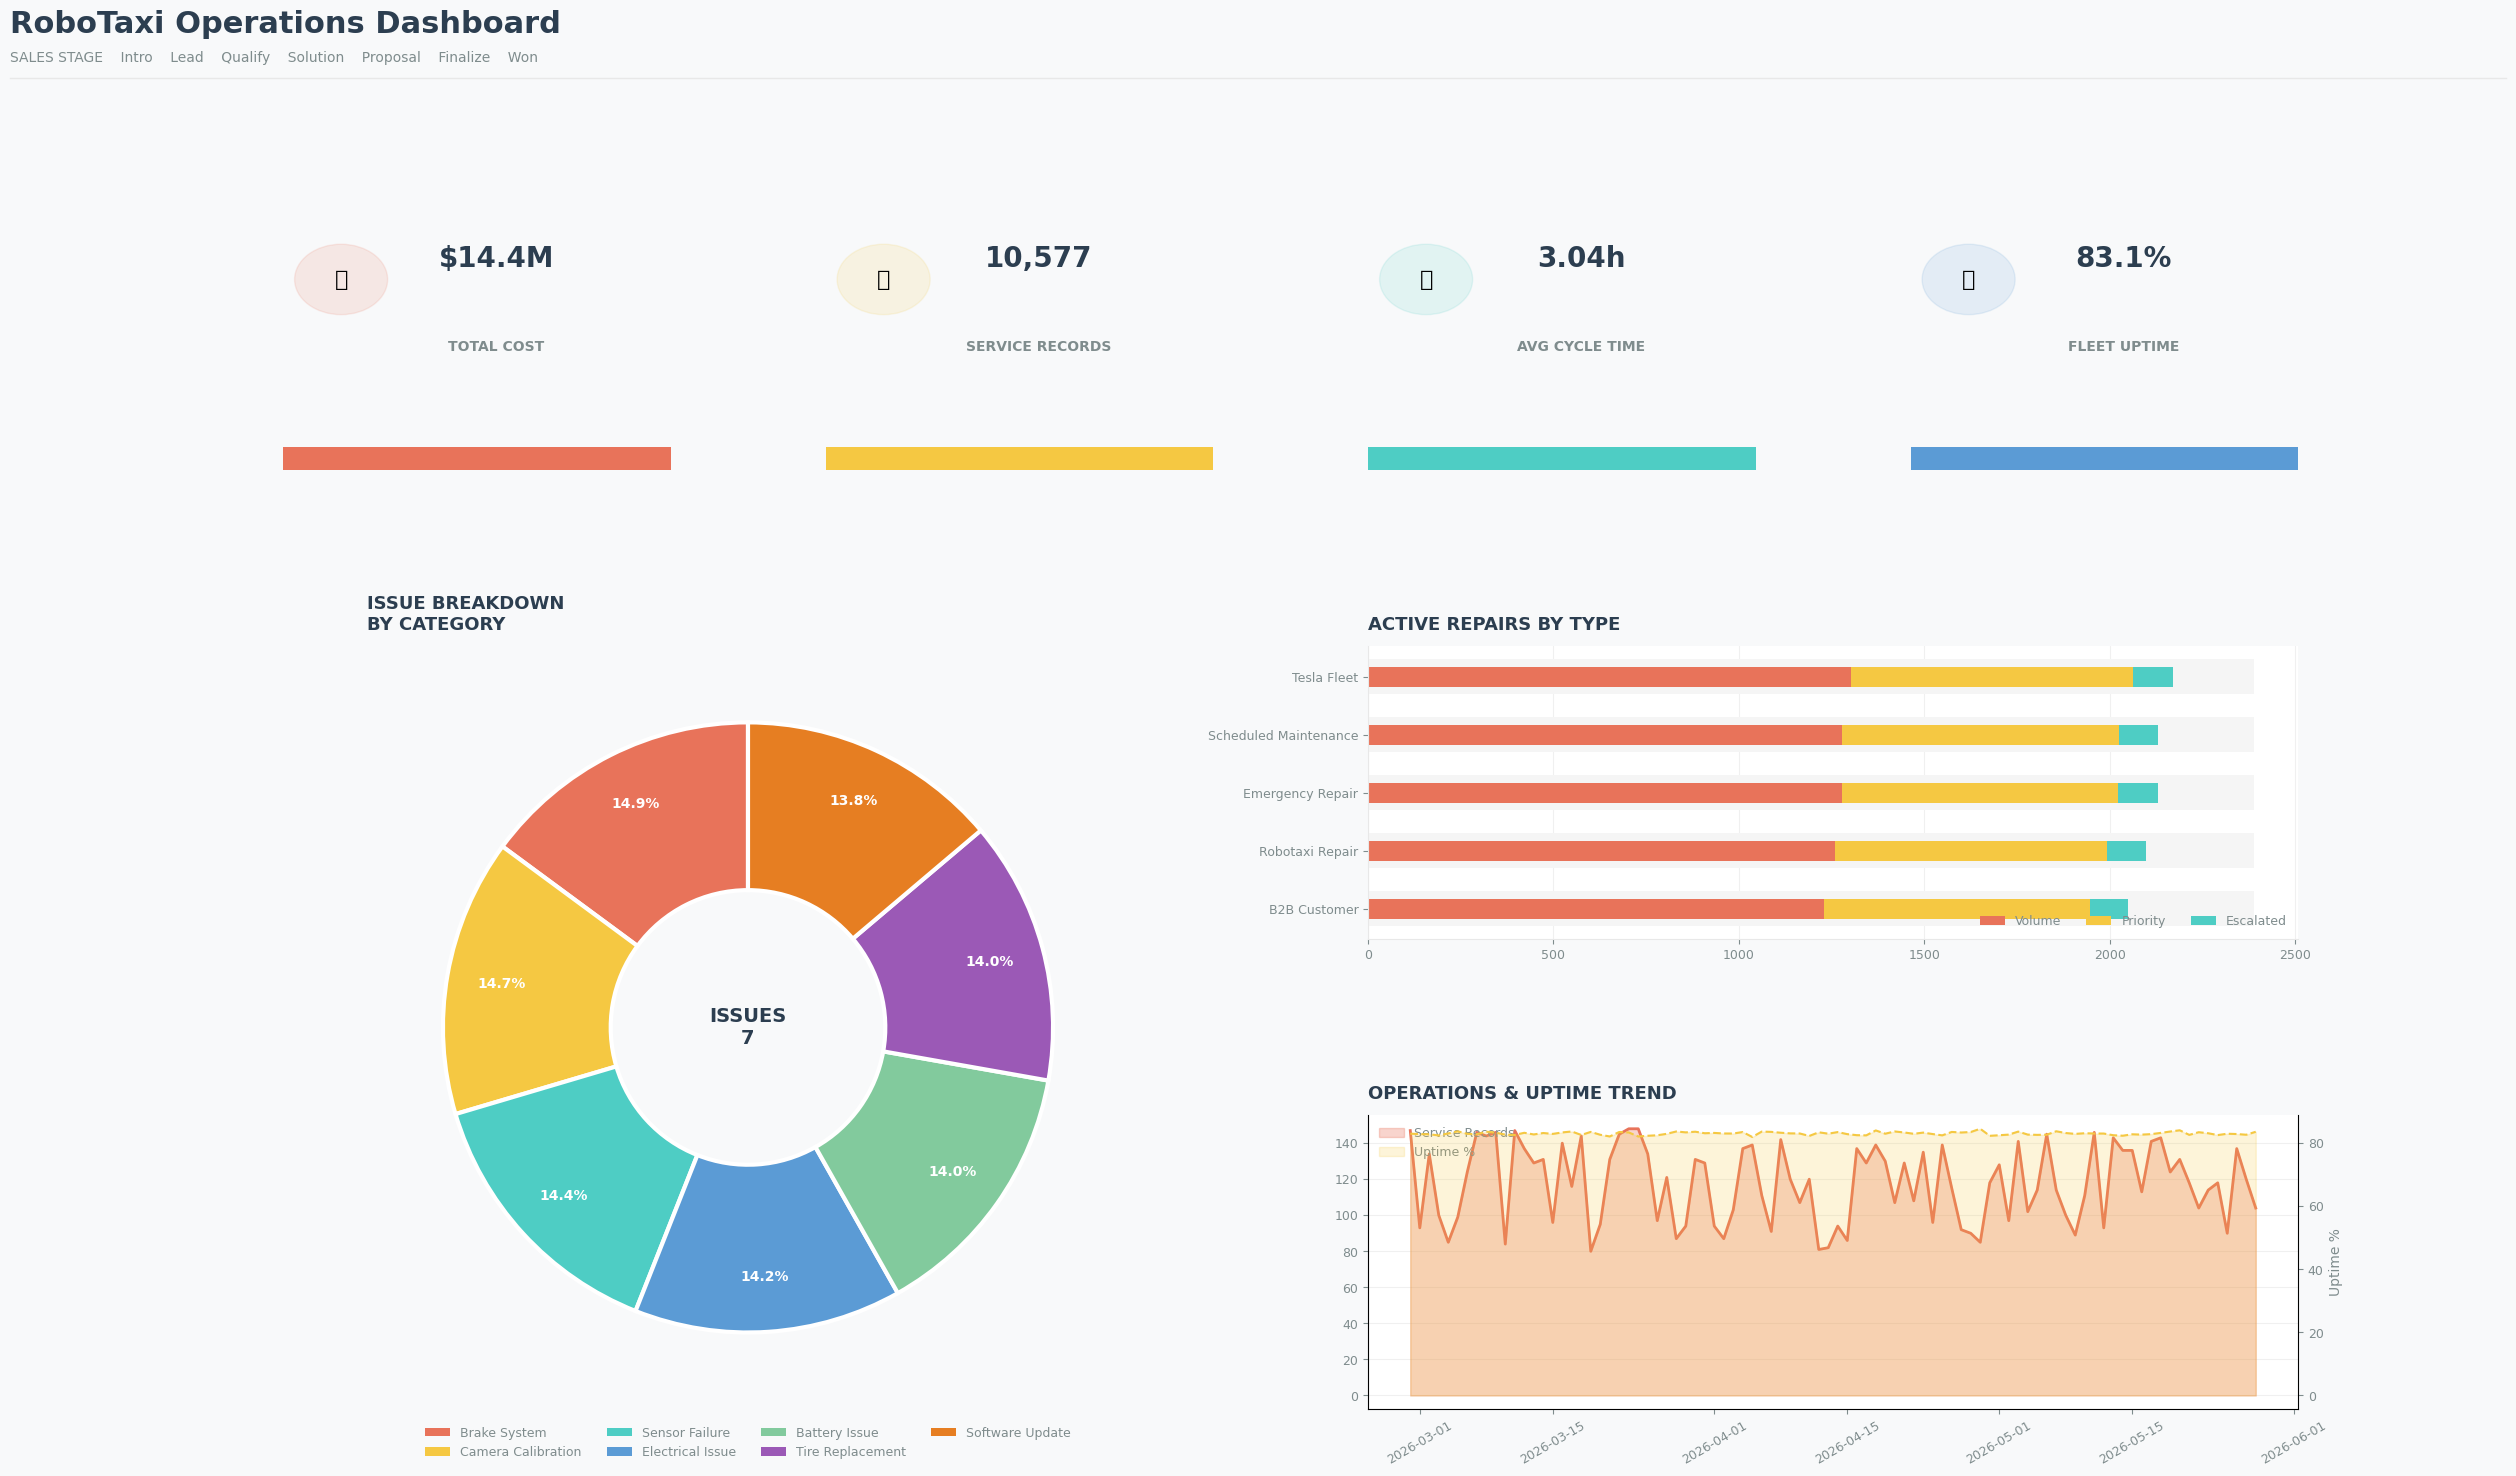

Dashboard created!


In [7]:
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

plt.style.use('default')

fig = plt.figure(figsize=(26, 16))
fig.patch.set_facecolor('#f8f9fa')

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.6, wspace=0.4)

CORAL = '#e8735a'
GOLD = '#f5c842'
TEAL = '#4ecdc4'
BLUE = '#5b9bd5'
GREEN = '#82ca9d'
PURPLE = '#9b59b6'
CARD_BG = '#ffffff'
TEXT_DARK = '#2c3e50'
TEXT_GRAY = '#7f8c8d'
BORDER = '#e8e8e8'

# ── HEADER ─────────────────────────────────────────
fig.text(0.02, 0.97, 'RoboTaxi Operations Dashboard',
         ha='left', fontsize=22, fontweight='bold', color=TEXT_DARK)
fig.text(0.02, 0.952,
         f'SALES STAGE    Intro    Lead    Qualify    Solution    Proposal    Finalize    Won',
         ha='left', fontsize=10, color=TEXT_GRAY)
fig.add_artist(plt.Line2D([0.02, 0.98], [0.942, 0.942],
               color=BORDER, linewidth=1.0, transform=fig.transFigure))

# ── KPI CARDS ──────────────────────────────────────
kpi_data = [
    ('TOTAL COST', f'${ops_df["total_cost"].sum()/1e6:.1f}M', CORAL, '💰'),
    ('SERVICE RECORDS', f'{len(ops_df):,}', GOLD, '🔧'),
    ('AVG CYCLE TIME', f'{ops_df["service_cycle_time_hrs"].mean():.2f}h', TEAL, '⏱'),
    ('FLEET UPTIME', f'{ops_df["fleet_uptime_pct"].mean():.1f}%', BLUE, '📡'),
]

for idx, (label, value, color, icon) in enumerate(kpi_data):
    ax_kpi = fig.add_subplot(gs[0, idx])
    ax_kpi.set_facecolor(CARD_BG)
    for spine in ax_kpi.spines.values():
        spine.set_color(BORDER)
    ax_kpi.axis('off')
    circle = plt.Circle((0.15, 0.65), 0.12, color=color + '22',
                         transform=ax_kpi.transAxes, zorder=2)
    ax_kpi.add_patch(circle)
    ax_kpi.text(0.15, 0.65, icon, ha='center', va='center',
                transform=ax_kpi.transAxes, fontsize=16)
    ax_kpi.text(0.55, 0.72, value, ha='center', va='center',
                transform=ax_kpi.transAxes, fontsize=20,
                fontweight='bold', color=TEXT_DARK)
    ax_kpi.text(0.55, 0.42, label, ha='center', va='center',
                transform=ax_kpi.transAxes, fontsize=10,
                color=TEXT_GRAY, fontweight='bold')
    rect = mpatches.FancyBboxPatch((0.0, 0.0), 1.0, 0.08,
                                    boxstyle="square,pad=0",
                                    facecolor=color, edgecolor='none',
                                    transform=ax_kpi.transAxes)
    ax_kpi.add_patch(rect)

# ── CHART 1: Issue Breakdown Donut ─────────────────
ax1 = fig.add_subplot(gs[1:3, 0:2])
ax1.set_facecolor(CARD_BG)
for spine in ax1.spines.values():
    spine.set_color(BORDER)
issue_counts = ops_df['issue_category'].value_counts()
colors_pie = [CORAL, GOLD, TEAL, BLUE, GREEN, PURPLE, '#e67e22']
wedges, texts, autotexts = ax1.pie(
    issue_counts.values,
    colors=colors_pie[:len(issue_counts)],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 3, 'width': 0.55}
)
for text in texts:
    text.set_visible(False)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
ax1.text(0, 0, 'ISSUES\n7', ha='center', va='center',
         fontsize=14, fontweight='bold', color=TEXT_DARK)
ax1.set_title('ISSUE BREAKDOWN\nBY CATEGORY', color=TEXT_DARK,
              fontweight='bold', pad=12, fontsize=13, loc='left')
legend_elements = [mpatches.Patch(facecolor=colors_pie[i], label=issue_counts.index[i])
                   for i in range(len(issue_counts))]
ax1.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=9, frameon=False, labelcolor=TEXT_GRAY,
           bbox_to_anchor=(0.5, -0.08))

# ── CHART 2: Active Repairs by Type ────────────────
ax2 = fig.add_subplot(gs[1, 2:4])
ax2.set_facecolor(CARD_BG)
for spine in ax2.spines.values():
    spine.set_color(BORDER)
repair_data = ops_df.groupby('repair_type').agg(
    count=('vehicle_id', 'count')).reset_index().sort_values('count', ascending=True)
y_pos = range(len(repair_data))
ax2.barh(y_pos, [repair_data['count'].max()*1.1]*len(repair_data),
         color='#f5f5f5', edgecolor='none', height=0.6)
ax2.barh(y_pos, repair_data['count'] * 0.6,
         color=CORAL, edgecolor='none', height=0.35, label='Volume')
ax2.barh(y_pos, repair_data['count'] * 0.35, color=GOLD,
         edgecolor='none', height=0.35,
         left=repair_data['count'] * 0.6, label='Priority')
ax2.barh(y_pos, repair_data['count'] * 0.05, color=TEAL,
         edgecolor='none', height=0.35,
         left=repair_data['count'] * 0.95, label='Escalated')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(repair_data['repair_type'], color=TEXT_GRAY, fontsize=10)
ax2.set_title('ACTIVE REPAIRS BY TYPE', color=TEXT_DARK,
              fontweight='bold', pad=12, fontsize=13, loc='left')
ax2.tick_params(colors=TEXT_GRAY, labelsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='x', color='#f0f0f0', linewidth=0.8)
ax2.set_axisbelow(True)
ax2.legend(fontsize=9, frameon=False, labelcolor=TEXT_GRAY,
           loc='lower right', ncol=3)

# ── CHART 3: Operations & Uptime Trend ─────────────
ax3 = fig.add_subplot(gs[2, 2:4])
ax3.set_facecolor(CARD_BG)
for spine in ax3.spines.values():
    spine.set_color(BORDER)
daily_ops = ops_df.groupby('date').agg(
    records=('vehicle_id', 'count'),
    uptime=('fleet_uptime_pct', 'mean')
).reset_index()
ax3.fill_between(daily_ops['date'], daily_ops['records'],
                 alpha=0.3, color=CORAL, label='Service Records')
ax3.plot(daily_ops['date'], daily_ops['records'], color=CORAL, linewidth=2)
ax3_twin = ax3.twinx()
ax3_twin.fill_between(daily_ops['date'], daily_ops['uptime'],
                      alpha=0.2, color=GOLD, label='Uptime %')
ax3_twin.plot(daily_ops['date'], daily_ops['uptime'],
              color=GOLD, linewidth=1.5, linestyle='--')
ax3_twin.tick_params(colors=TEXT_GRAY, labelsize=9)
ax3_twin.spines['top'].set_visible(False)
ax3_twin.set_ylabel('Uptime %', color=TEXT_GRAY, fontsize=10)
ax3.set_title('OPERATIONS & UPTIME TREND', color=TEXT_DARK,
              fontweight='bold', pad=12, fontsize=13, loc='left')
ax3.tick_params(colors=TEXT_GRAY, labelsize=9, axis='x', rotation=30)
ax3.tick_params(colors=TEXT_GRAY, labelsize=9, axis='y')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='y', color='#f0f0f0', linewidth=0.8)
ax3.set_axisbelow(True)
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=9,
           frameon=False, labelcolor=TEXT_GRAY, loc='upper left')

plt.savefig('robotaxi_dashboard_light.png', dpi=150, bbox_inches='tight',
            facecolor='#f8f9fa')
plt.show()
print("Dashboard created!")

In [8]:
from google.colab import files

# Save dataset
ops_df.to_csv('robotaxi_operations_data.csv', index=False)

# Save results markdown
results = """
# RoboTaxi Operations Analytics Dashboard

## Operations Overview
- **Total Vehicles Tracked:** 200
- **Total Service Records:** {:,}
- **Days of Data:** 90
- **Total Operations Cost:** ${:.2f}M

## Key Performance Indicators
- **Avg Service Cycle Time:** {:.2f} hours
- **Avg Fleet Uptime:** {:.2f}%
- **Avg MTBF:** {:.0f} hours
- **Avg Resolution Rate:** {:.1f}%

## Analysis Performed
1. Service Cycle Time by Repair Type
2. Fleet Uptime % by Region
3. Daily Operations Trend (90 Days)
4. Mean Time Between Failures by Vehicle Model
5. Issue Category Breakdown
6. Key Operations Indicators (KPI Cards)

## Technologies
- Python, Pandas, NumPy
- Matplotlib, Seaborn
- Google Colab (T4 GPU)

## Regions Covered
- Phoenix AZ, Austin TX, Las Vegas NV, San Francisco CA, Miami FL
""".format(
    len(ops_df),
    ops_df['total_cost'].sum()/1e6,
    ops_df['service_cycle_time_hrs'].mean(),
    ops_df['fleet_uptime_pct'].mean(),
    ops_df['mtbf_hours'].mean(),
    ops_df['resolution_rate'].mean()*100
)

with open('README_results.md', 'w') as f:
    f.write(results)

print("Downloading files...")
files.download('robotaxi_dashboard_light.png')
files.download('robotaxi_operations_data.csv')
files.download('README_results.md')
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
